# Stage 2 — Clean Baseline Models

This notebook trains and evaluates clean-data baseline models for the two verified tasks:

1. Sentiment classification
2. Topic classification

The baselines are:

- Majority Class Classifier
- Word-level TF-IDF + Linear SVM
- Character-level TF-IDF + Linear SVM

The main metric is **Macro-F1** because Stage 1 showed strong class imbalance, especially for `neutral`, `facility`, and `others`.

This notebook uses processed files from Stage 1:

- `data/processed/train.csv`
- `data/processed/dev.csv`
- `data/processed/test.csv`
- `configs/label_mapping.json`


## 1. Imports and project paths

In [1]:
from pathlib import Path
import json
import sys
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt

# Detect project root.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

CONFIG_DIR = PROJECT_ROOT / "configs"
MODELS_DIR = PROJECT_ROOT / "models" / "baselines"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"
NOTES_DIR = REPORTS_DIR / "notes"

for path in [MODELS_DIR, FIGURES_DIR, TABLES_DIR, NOTES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

from src.preprocessing import prepare_text_series
from src.train_baseline import get_baseline_builders
from src.evaluate import train_and_evaluate_model

print("Project root:", PROJECT_ROOT)
print("Processed data dir:", PROCESSED_DIR)


Project root: d:\project-ml-engineering\nlp-phobert-student-feedback
Processed data dir: d:\project-ml-engineering\nlp-phobert-student-feedback\data\processed


## 2. Load processed data from Stage 1

In [2]:
train_path = PROCESSED_DIR / "train.csv"
dev_path = PROCESSED_DIR / "dev.csv"
test_path = PROCESSED_DIR / "test.csv"

required_files = [train_path, dev_path, test_path, CONFIG_DIR / "label_mapping.json"]

for file_path in required_files:
    if not file_path.exists():
        raise FileNotFoundError(f"Required Stage 1 file is missing: {file_path}")

train_df = pd.read_csv(train_path)
dev_df = pd.read_csv(dev_path)
test_df = pd.read_csv(test_path)

print("Train:", train_df.shape)
print("Dev:", dev_df.shape)
print("Test:", test_df.shape)

display(train_df.head())


Train: (11426, 9)
Dev: (1583, 9)
Test: (3166, 9)


,id,split,text,sentiment_label_raw,sentiment_label,topic_label_raw,topic_label,char_count,raw_word_count
0,train_0,train,slide giáo trình đầy đủ .,2,positive,1,training_program,25,6
1,train_1,train,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,positive,0,lecturer,46,11
2,train_2,train,đi học đầy đủ full điểm chuyên cần .,0,negative,1,training_program,36,9
3,train_3,train,chưa áp dụng công nghệ thông tin và các thiết ...,0,negative,0,lecturer,76,18
4,train_4,train,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,positive,0,lecturer,59,15


## 3. Load label mapping

In [3]:
with open(CONFIG_DIR / "label_mapping.json", "r", encoding="utf-8") as f:
    label_mapping = json.load(f)

sentiment_labels = list(label_mapping["sentiment"]["id_to_name"].values())
topic_labels = list(label_mapping["topic"]["id_to_name"].values())

print("Sentiment labels:", sentiment_labels)
print("Topic labels:", topic_labels)
print(json.dumps(label_mapping, ensure_ascii=False, indent=2))


Sentiment labels: ['negative', 'neutral', 'positive']
Topic labels: ['lecturer', 'training_program', 'facility', 'others']
{
  "dataset_name": "uitnlp/vietnamese_students_feedback",
  "created_at": "2026-06-18T01:03:51",
  "sentiment": {
    "source_column": "sentiment",
    "verified_from_hf_features": true,
    "id_to_name": {
      "0": "negative",
      "1": "neutral",
      "2": "positive"
    }
  },
  "topic": {
    "source_column": "topic",
    "verified_from_hf_features": true,
    "id_to_name": {
      "0": "lecturer",
      "1": "training_program",
      "2": "facility",
      "3": "others"
    }
  }
}


## 4. Minimal text preprocessing

In [4]:
for df_name, df in [("train", train_df), ("dev", dev_df), ("test", test_df)]:
    df["text"] = prepare_text_series(df["text"])

    if df["text"].isna().sum() > 0:
        raise ValueError(f"{df_name} still contains missing text values after preprocessing.")

    if (df["text"].str.len() == 0).sum() > 0:
        print(f"Warning: {df_name} contains empty text rows after preprocessing.")

print("Minimal preprocessing completed.")


Minimal preprocessing completed.


## 5. Sanity checks

We confirm that every task label exists in train, dev, and test. If a minority class is absent from a split, Macro-F1 would be misleading.


In [5]:
def check_label_coverage(frames: dict[str, pd.DataFrame], label_col: str, expected_labels: list[str]) -> pd.DataFrame:
    rows = []

    for split, df in frames.items():
        observed = set(df[label_col].dropna().unique().tolist())

        for label in expected_labels:
            rows.append({
                "split": split,
                "label_column": label_col,
                "label": label,
                "present": label in observed,
                "count": int((df[label_col] == label).sum()),
            })

    return pd.DataFrame(rows)


frames = {
    "train": train_df,
    "dev": dev_df,
    "test": test_df,
}

sentiment_coverage = check_label_coverage(frames, "sentiment_label", sentiment_labels)
topic_coverage = check_label_coverage(frames, "topic_label", topic_labels)

display(sentiment_coverage)
display(topic_coverage)

if not sentiment_coverage["present"].all():
    raise ValueError("At least one sentiment label is missing in one split.")

if not topic_coverage["present"].all():
    raise ValueError("At least one topic label is missing in one split.")


,split,label_column,label,present,count
0,train,sentiment_label,negative,True,5325
1,train,sentiment_label,neutral,True,458
2,train,sentiment_label,positive,True,5643
3,dev,sentiment_label,negative,True,705
4,dev,sentiment_label,neutral,True,73
5,dev,sentiment_label,positive,True,805
6,test,sentiment_label,negative,True,1409
7,test,sentiment_label,neutral,True,167
8,test,sentiment_label,positive,True,1590


,split,label_column,label,present,count
0,train,topic_label,lecturer,True,8166
1,train,topic_label,training_program,True,2201
2,train,topic_label,facility,True,497
3,train,topic_label,others,True,562
4,dev,topic_label,lecturer,True,1151
5,dev,topic_label,training_program,True,267
6,dev,topic_label,facility,True,70
7,dev,topic_label,others,True,95
8,test,topic_label,lecturer,True,2290
9,test,topic_label,training_program,True,572


## 6. Train and evaluate baselines

Model selection policy:

- Train on `train`
- Compare on `dev`
- Report final result on `test`
- Do not tune hyperparameters on `test`



Task: sentiment

Training: majority_class


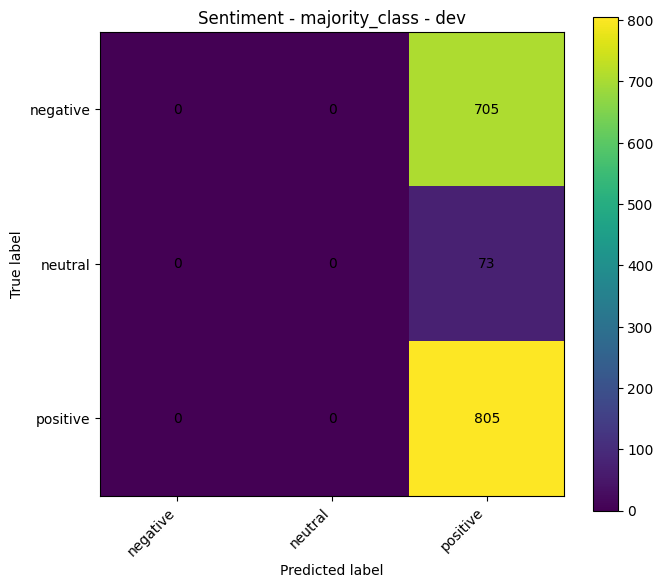

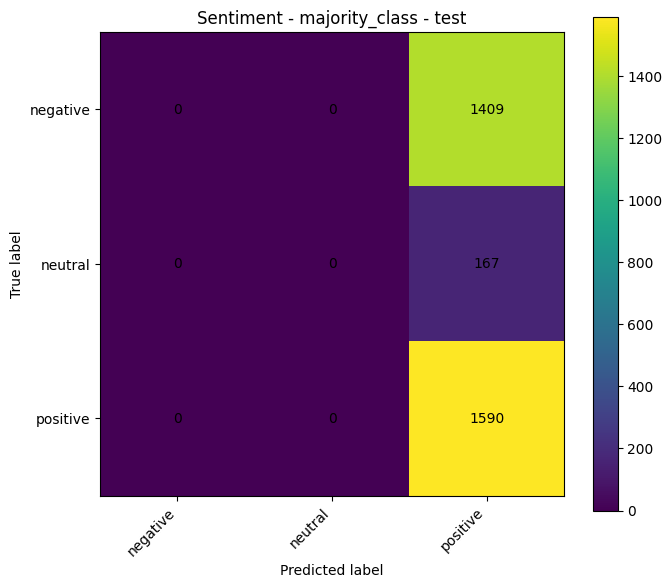


Training: tfidf_word_svm


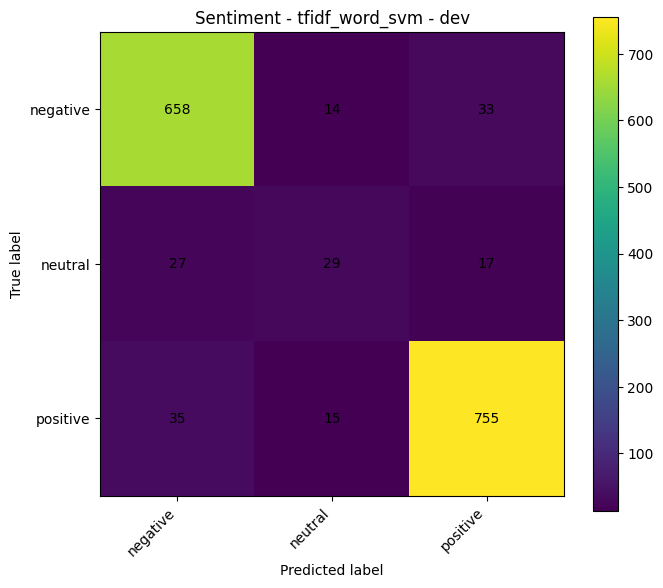

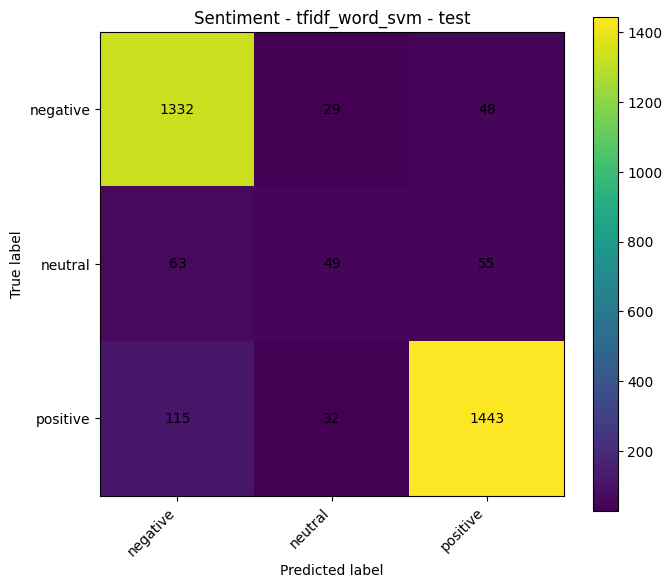


Training: tfidf_char_svm


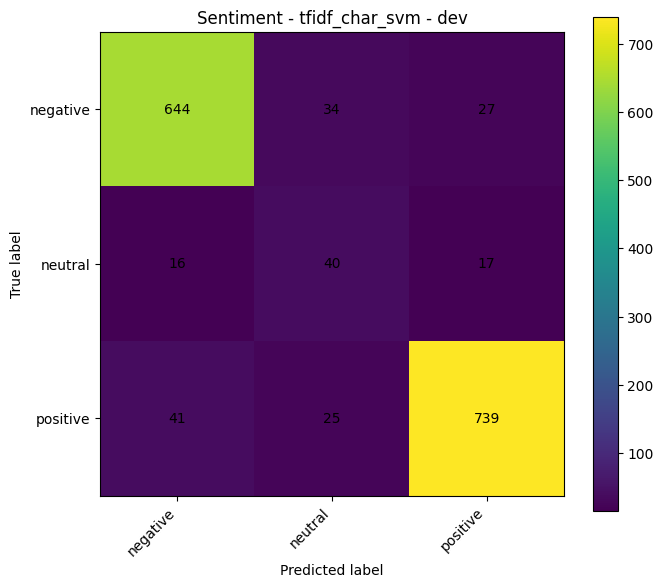

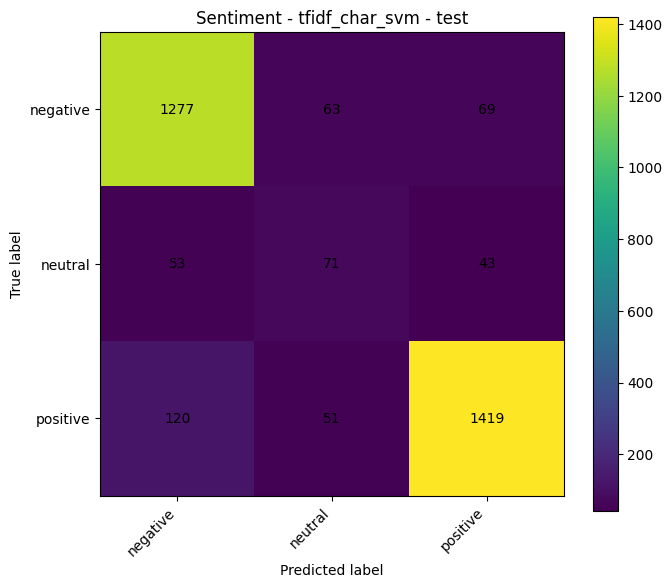


Task: topic

Training: majority_class


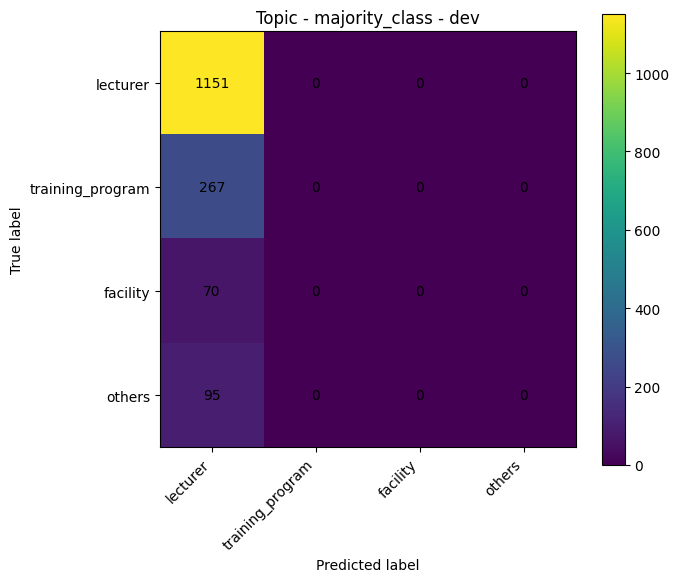

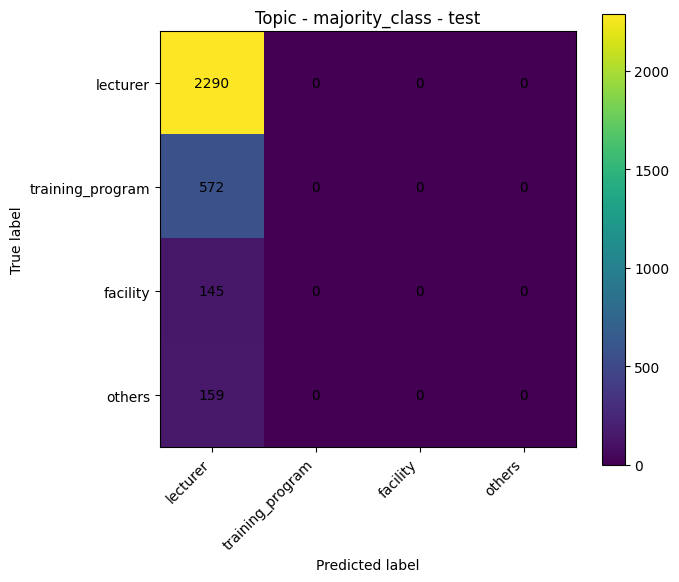


Training: tfidf_word_svm


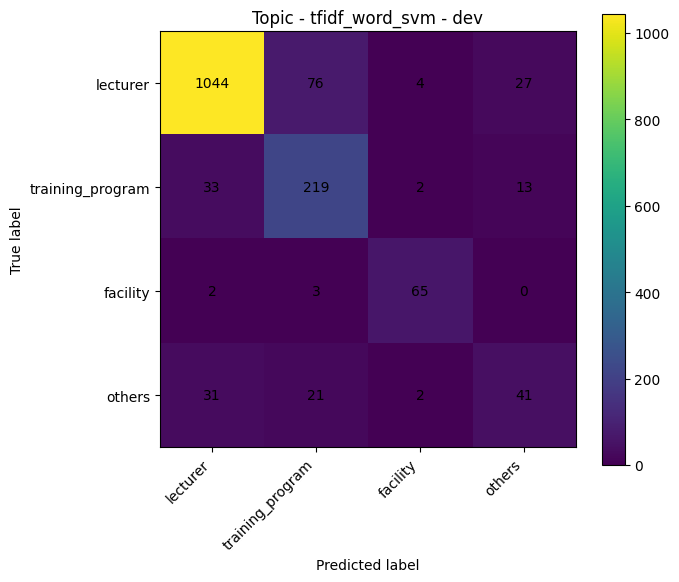

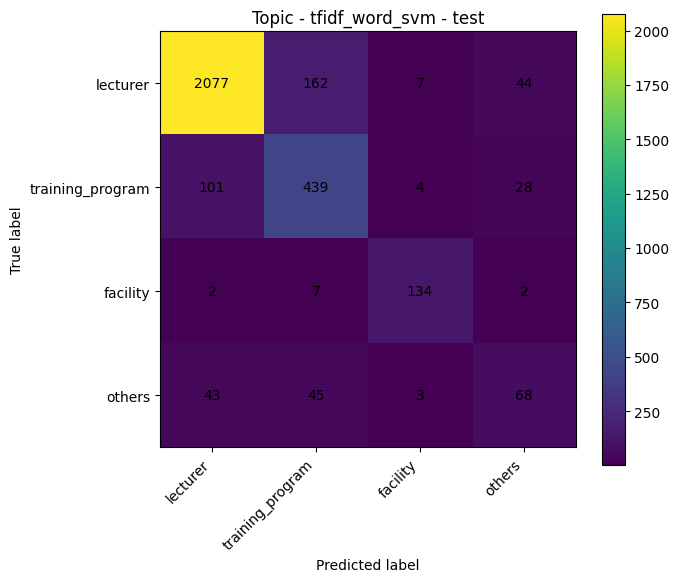


Training: tfidf_char_svm


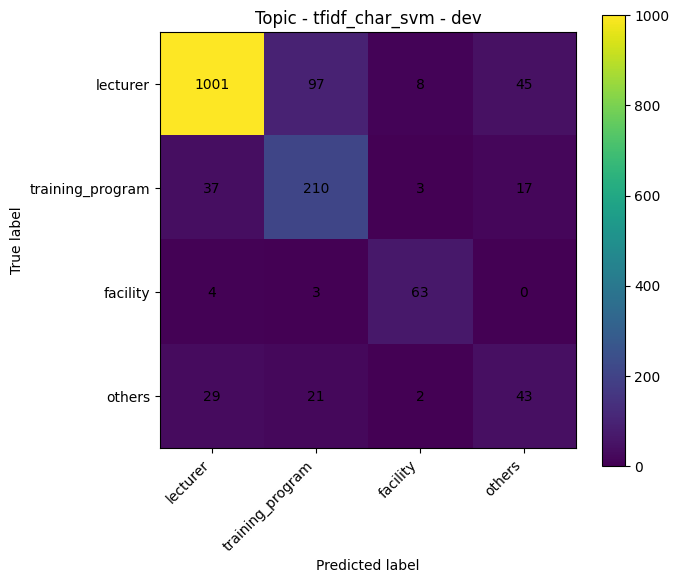

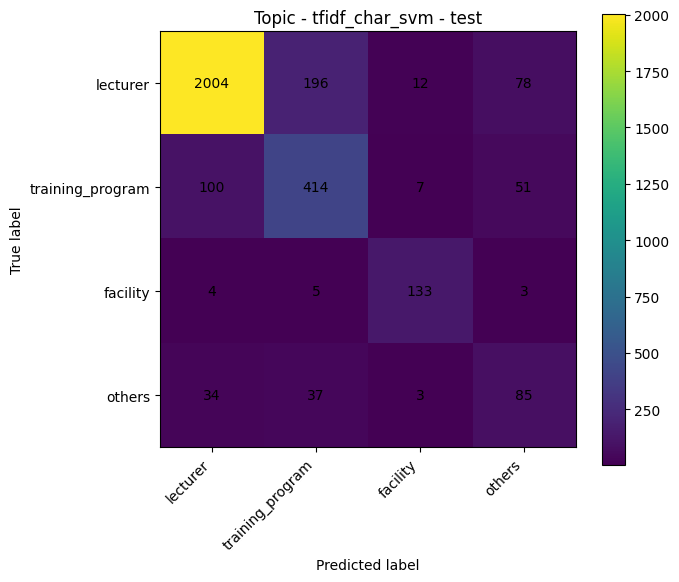


Finished baseline training and evaluation.


In [6]:
baseline_builders = get_baseline_builders()

tasks = {
    "sentiment": {
        "label_col": "sentiment_label",
        "labels": sentiment_labels,
    },
    "topic": {
        "label_col": "topic_label",
        "labels": topic_labels,
    },
}

summary_rows = []
classification_report_frames = []

eval_frames = {
    "dev": dev_df,
    "test": test_df,
}

for task, task_config in tasks.items():
    print("\n" + "=" * 100)
    print("Task:", task)

    label_col = task_config["label_col"]
    labels = task_config["labels"]

    for model_name, build_model in baseline_builders.items():
        print("\nTraining:", model_name)

        model = build_model()

        model_summary_rows, model_report_frames = train_and_evaluate_model(
            model=model,
            model_name=model_name,
            task=task,
            train_df=train_df,
            eval_frames=eval_frames,
            text_col="text",
            label_col=label_col,
            labels=labels,
            models_dir=MODELS_DIR,
            reports_tables_dir=TABLES_DIR,
            reports_figures_dir=FIGURES_DIR,
            output_prefix="02",
        )

        summary_rows.extend(model_summary_rows)
        classification_report_frames.extend(model_report_frames)

print("\nFinished baseline training and evaluation.")


## 7. Save summary tables

In [7]:
baseline_results = pd.DataFrame(summary_rows)

# Round numeric metrics for readability in display.
display_columns = [
    "task",
    "model_name",
    "split",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "train_time_sec",
    "predict_time_sec",
    "num_train_samples",
    "num_eval_samples",
]

baseline_results_display = baseline_results[display_columns].copy()

for col in ["accuracy", "macro_f1", "weighted_f1", "train_time_sec", "predict_time_sec"]:
    baseline_results_display[col] = baseline_results_display[col].round(4)

baseline_results_path = TABLES_DIR / "02_baseline_results_summary.csv"
baseline_results.to_csv(baseline_results_path, index=False, encoding="utf-8-sig")

display(baseline_results_display)
print("Saved:", baseline_results_path)

classification_reports = pd.concat(classification_report_frames, ignore_index=True)

classification_reports_path = TABLES_DIR / "02_baseline_classification_reports.csv"
classification_reports.to_csv(classification_reports_path, index=False, encoding="utf-8-sig")

# Task-specific report files for easier reading.
classification_reports[classification_reports["task"] == "sentiment"].to_csv(
    TABLES_DIR / "02_baseline_sentiment_classification_report.csv",
    index=False,
    encoding="utf-8-sig",
)

classification_reports[classification_reports["task"] == "topic"].to_csv(
    TABLES_DIR / "02_baseline_topic_classification_report.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Saved:", classification_reports_path)


,task,model_name,split,accuracy,macro_f1,weighted_f1,train_time_sec,predict_time_sec,num_train_samples,num_eval_samples
0,sentiment,majority_class,dev,0.5085,0.2247,0.3429,0.0065,0.0002,11426,1583
1,sentiment,majority_class,test,0.5022,0.2229,0.3358,0.0065,0.0002,11426,3166
2,sentiment,tfidf_word_svm,dev,0.9109,0.7680,0.9087,1.0087,0.0704,11426,1583
3,sentiment,tfidf_word_svm,test,0.8920,0.7289,0.8870,1.0087,0.1450,11426,3166
4,sentiment,tfidf_char_svm,dev,0.8989,0.7706,0.9027,2.6158,0.1901,11426,1583
5,sentiment,tfidf_char_svm,test,0.8740,0.7354,0.8755,2.6158,0.4349,11426,3166
6,topic,majority_class,dev,0.7271,0.2105,0.6122,0.0102,0.0002,11426,1583
7,topic,majority_class,test,0.7233,0.2099,0.6072,0.0102,0.0001,11426,3166
8,topic,tfidf_word_svm,dev,0.8648,0.7615,0.8657,0.9540,0.0702,11426,1583
9,topic,tfidf_word_svm,test,0.8585,0.7509,0.8598,0.9540,0.1313,11426,3166


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\02_baseline_results_summary.csv
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\02_baseline_classification_reports.csv


## 8. Compare baseline Macro-F1

task,sentiment,topic
model_name,,
majority_class,0.2229,0.2099
tfidf_char_svm,0.7354,0.7299
tfidf_word_svm,0.7289,0.7509


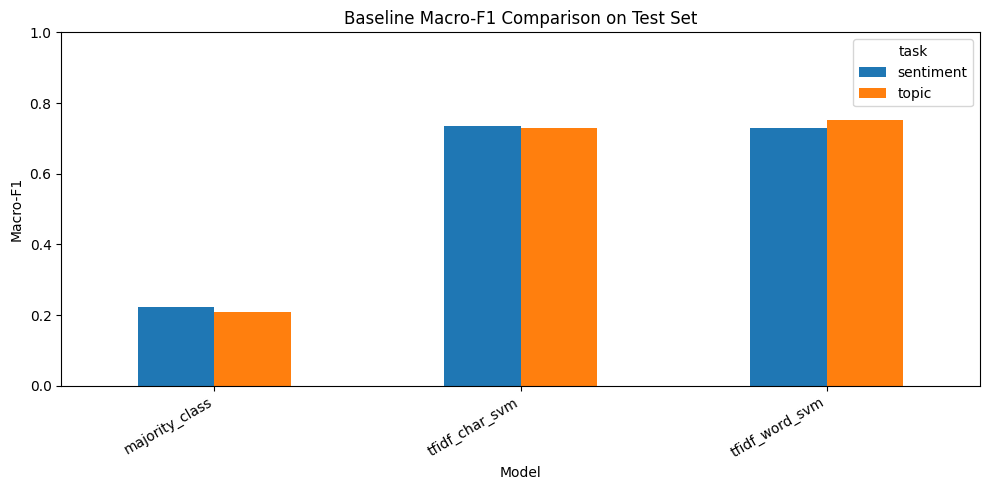

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\02_baseline_macro_f1_comparison.png


In [8]:
test_results = baseline_results[baseline_results["split"] == "test"].copy()
dev_results = baseline_results[baseline_results["split"] == "dev"].copy()

comparison_pivot = test_results.pivot_table(
    index="model_name",
    columns="task",
    values="macro_f1",
    aggfunc="mean",
)

display(comparison_pivot.round(4))

ax = comparison_pivot.plot(kind="bar", figsize=(10, 5))
ax.set_title("Baseline Macro-F1 Comparison on Test Set")
ax.set_xlabel("Model")
ax.set_ylabel("Macro-F1")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

macro_f1_fig_path = FIGURES_DIR / "02_baseline_macro_f1_comparison.png"
plt.savefig(macro_f1_fig_path, dpi=150)
plt.show()

print("Saved:", macro_f1_fig_path)


## 9. Select best baseline by dev Macro-F1

In [9]:
best_baselines = (
    dev_results.sort_values(["task", "macro_f1"], ascending=[True, False])
    .groupby("task")
    .head(1)
    .reset_index(drop=True)
)

best_baselines_path = TABLES_DIR / "02_best_baseline_by_dev_macro_f1.csv"
best_baselines.to_csv(best_baselines_path, index=False, encoding="utf-8-sig")

display(best_baselines[[
    "task",
    "model_name",
    "split",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "model_path",
]].round(4))

print("Saved:", best_baselines_path)


,task,model_name,split,accuracy,macro_f1,weighted_f1,model_path
0,sentiment,tfidf_char_svm,dev,0.8989,0.7706,0.9027,d:\project-ml-engineering\nlp-phobert-student-...
1,topic,tfidf_word_svm,dev,0.8648,0.7615,0.8657,d:\project-ml-engineering\nlp-phobert-student-...


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\02_best_baseline_by_dev_macro_f1.csv


## 10. Minority-class quick review

In [10]:
# Show per-class F1 on test for easier inspection of minority class behavior.
test_class_reports = classification_reports[
    (classification_reports["split"] == "test")
    & (~classification_reports["label"].isin(["accuracy", "macro avg", "weighted avg"]))
].copy()

test_class_reports["f1-score"] = pd.to_numeric(test_class_reports["f1-score"], errors="coerce")

minority_review = test_class_reports.sort_values(
    ["task", "model_name", "f1-score"],
    ascending=[True, True, True],
)

minority_review_path = TABLES_DIR / "02_baseline_minority_class_review_test.csv"
minority_review.to_csv(minority_review_path, index=False, encoding="utf-8-sig")

display(minority_review[[
    "task",
    "model_name",
    "label",
    "precision",
    "recall",
    "f1-score",
    "support",
]].round(4))

print("Saved:", minority_review_path)


,task,model_name,label,precision,recall,f1-score,support
6,sentiment,majority_class,negative,0.0000,0.0000,0.0000,1409.0
7,sentiment,majority_class,neutral,0.0000,0.0000,0.0000,167.0
8,sentiment,majority_class,positive,0.5022,1.0000,0.6686,1590.0
31,sentiment,tfidf_char_svm,neutral,0.3838,0.4251,0.4034,167.0
30,sentiment,tfidf_char_svm,negative,0.8807,0.9063,0.8933,1409.0
32,sentiment,tfidf_char_svm,positive,0.9268,0.8925,0.9093,1590.0
19,sentiment,tfidf_word_svm,neutral,0.4455,0.2934,0.3538,167.0
18,sentiment,tfidf_word_svm,negative,0.8821,0.9454,0.9126,1409.0
20,sentiment,tfidf_word_svm,positive,0.9334,0.9075,0.9203,1590.0
44,topic,majority_class,training_program,0.0000,0.0000,0.0000,572.0


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\02_baseline_minority_class_review_test.csv


## 11. Generate baseline modeling report

In [11]:
def dataframe_to_markdown(df: pd.DataFrame) -> str:
    """Convert a small DataFrame to markdown without requiring tabulate."""
    if df.empty:
        return "_Empty table_"

    safe_df = df.copy()
    for col in safe_df.columns:
        safe_df[col] = safe_df[col].astype(str)

    headers = safe_df.columns.tolist()
    lines = []
    lines.append("| " + " | ".join(headers) + " |")
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")

    for _, row in safe_df.iterrows():
        lines.append("| " + " | ".join(row[col] for col in headers) + " |")

    return "\n".join(lines)


report_lines = []

report_lines.append("# Baseline Modeling Report\n")
report_lines.append(f"- Created at: `{datetime.now().isoformat(timespec='seconds')}`")
report_lines.append("- Data source: processed UIT-VSFC splits from Stage 1")
report_lines.append("- Main metric: Macro-F1")
report_lines.append("- Model selection split: dev")
report_lines.append("- Final reporting split: test\n")

report_lines.append("## Tasks\n")
report_lines.append("- Sentiment classification")
report_lines.append("- Topic classification\n")

report_lines.append("## Models\n")
report_lines.append("1. Majority Class Classifier")
report_lines.append("2. Word-level TF-IDF + Linear SVM")
report_lines.append("3. Character-level TF-IDF + Linear SVM\n")

report_lines.append("## Preprocessing policy\n")
report_lines.append(
    "Only minimal text preprocessing is used: convert to string and strip whitespace. "
    "No accent removal, spelling correction, abbreviation normalization, or stopword removal "
    "is applied in this clean baseline stage.\n"
)

report_lines.append("## Baseline results on test split\n")
test_report_table = test_results[[
    "task",
    "model_name",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "train_time_sec",
    "predict_time_sec",
]].copy()

for col in ["accuracy", "macro_f1", "weighted_f1", "train_time_sec", "predict_time_sec"]:
    test_report_table[col] = test_report_table[col].round(4)

report_lines.append(dataframe_to_markdown(test_report_table))
report_lines.append("\n")

report_lines.append("## Best baseline by dev Macro-F1\n")
best_table = best_baselines[[
    "task",
    "model_name",
    "accuracy",
    "macro_f1",
    "weighted_f1",
]].copy()

for col in ["accuracy", "macro_f1", "weighted_f1"]:
    best_table[col] = best_table[col].round(4)

report_lines.append(dataframe_to_markdown(best_table))
report_lines.append("\n")

report_lines.append("## Notes\n")
report_lines.append(
    "- Accuracy is reported but not used as the main metric because both tasks are class-imbalanced.\n"
    "- Macro-F1 is used to reflect minority-class performance more clearly.\n"
    "- Confusion matrices and per-class reports are exported for later error analysis.\n"
)

report_path = NOTES_DIR / "02_baseline_modeling_report.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print("Saved:", report_path)


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\notes\02_baseline_modeling_report.md


## 12. Final Stage 2 output check

In [12]:
expected_files = [
    TABLES_DIR / "02_baseline_results_summary.csv",
    TABLES_DIR / "02_baseline_classification_reports.csv",
    TABLES_DIR / "02_baseline_sentiment_classification_report.csv",
    TABLES_DIR / "02_baseline_topic_classification_report.csv",
    TABLES_DIR / "02_best_baseline_by_dev_macro_f1.csv",
    TABLES_DIR / "02_baseline_minority_class_review_test.csv",
    FIGURES_DIR / "02_baseline_macro_f1_comparison.png",
    NOTES_DIR / "02_baseline_modeling_report.md",
]

for task in tasks.keys():
    for model_name in baseline_builders.keys():
        expected_files.append(MODELS_DIR / task / f"{model_name}.joblib")

print("Stage 2 output check:")

all_ok = True
for file_path in expected_files:
    exists = file_path.exists()
    all_ok = all_ok and exists
    print("[OK]     " if exists else "[MISSING]", file_path)

print("\nStage 2 completed:", all_ok)


Stage 2 output check:
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\02_baseline_results_summary.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\02_baseline_classification_reports.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\02_baseline_sentiment_classification_report.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\02_baseline_topic_classification_report.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\02_best_baseline_by_dev_macro_f1.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\02_baseline_minority_class_review_test.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\02_baseline_macro_f1_comparison.png
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\notes\02_baseline_modeling_report.md
[OK]      d:\project-ml-engi

## What to send for review

After running this notebook, send:

1. `reports/tables/02_baseline_results_summary.csv`
2. `reports/tables/02_best_baseline_by_dev_macro_f1.csv`
3. `reports/notes/02_baseline_modeling_report.md`
4. A screenshot or text of the final output check

Do not start PhoBERT fine-tuning until the baseline results are reviewed.
